========== KNN ==========
Accuracy: 0.9473684210526315

Confusion Matrix
[[40  3]
 [ 3 68]]

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

========== Decision Tree ==========
Accuracy: 0.9473684210526315

Confusion Matrix
[[40  3]
 [ 3 68]]

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



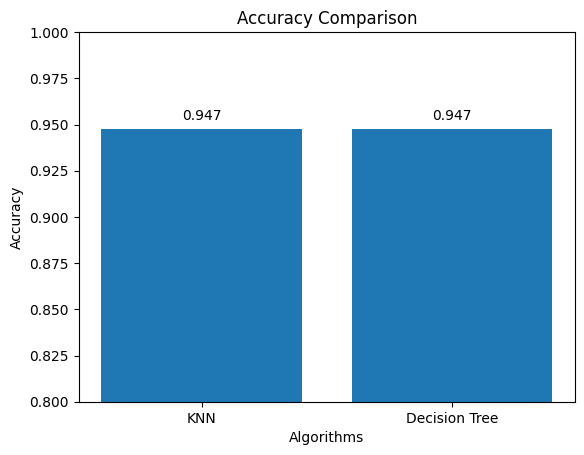

In [1]:
# Comparison of KNN and Decision Tree using Breast Cancer Dataset

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load Dataset
data = load_breast_cancer()

X = data.data
y = data.target

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling (Required for KNN)
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -------------------------
# KNN Algorithm
# -------------------------
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

print("========== KNN ==========")
print("Accuracy:", accuracy_score(y_test, knn_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, knn_pred))
print("\nClassification Report")
print(classification_report(y_test, knn_pred))

# -------------------------
# Decision Tree Algorithm
# -------------------------
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("========== Decision Tree ==========")
print("Accuracy:", accuracy_score(y_test, dt_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, dt_pred))
print("\nClassification Report")
print(classification_report(y_test, dt_pred))

# -------------------------
# Accuracy Comparison
# -------------------------
knn_accuracy = accuracy_score(y_test, knn_pred)
dt_accuracy = accuracy_score(y_test, dt_pred)

algorithms = ['KNN', 'Decision Tree']
accuracy = [knn_accuracy, dt_accuracy]

plt.bar(algorithms, accuracy)
plt.title("Accuracy Comparison")
plt.xlabel("Algorithms")
plt.ylabel("Accuracy")
plt.ylim(0.8, 1.0)

for i, value in enumerate(accuracy):
    plt.text(i, value + 0.005, f"{value:.3f}", ha='center')

plt.show()

# New Section